In [98]:
import glob
import polars as pl
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
from datetime import datetime


In [99]:
def load_ndjson(file_path):
    with open(file_path, 'r') as file:
        data = [json.loads(line) for line in file]
    return data

def convert_time_to_seconds(time_str):
    # Extract the time part (hhmmss.SSS)
    time_part = time_str.split('-')[1]
    # Parse the time part to a datetime object
    time_obj = datetime.strptime(time_part, '%H%M%S.%f')
    # Convert to seconds
    seconds = time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second + time_obj.microsecond / 1_000_000
    return seconds

def convert_since_creation_to_seconds(since_creation_str):
    return int(since_creation_str.replace('ms', '')) / 1000


In [100]:
dfs = []

for file in glob.glob("../data/real_data/*/*/*.log"):
    if os.stat(file).st_size == 0:
        print("File is empty, skipping:", file)
        continue
    file_parts  = file.split("/")[-1].split("-")
    round_nb = file.split("/")[-1].split("-")[0]
    dyad = file.split("/")[-1].split("-")[1]
    sid = file.split("/")[-3]

    data = load_ndjson(file)
    df = pd.DataFrame(data)
    df['time_seconds'] = df['time'].apply(convert_time_to_seconds)

    dfs.append(df)

In [101]:
all_data_df = pd.concat(dfs)

In [102]:
all_data_df['sinceCreation_seconds']     = all_data_df['sinceCreation'].str.replace('ms', '').astype(float) / 1000
all_data_df['sinceCreation_downsampled'] = (all_data_df['sinceCreation_seconds'] // 10) * 10


In [ ]:
# Import behavioral data and prepare for merge
behavior_df = pl.read_csv("../data/behavior/all_data_df.csv")
behavior_df.head()

remove_colons = lambda s: s.replace(":", "")

# Apply the lambda function to the specified column
behavior_df = behavior_df.with_columns(
    behavior_df['sid'].apply(remove_colons).alias('sid'),
    behavior_df['user_id'].apply(remove_colons).alias('user_id'),
    behavior_df['other_id'].apply(remove_colons).alias('other_id')
)

behavior_df = behavior_df.pivot(index=["sid", "dyad", "user_id", "other_id", "participant_condition", "other_condition"], columns="question_content", values="measure",aggregate_function="sum")

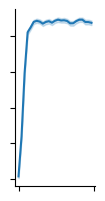

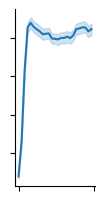

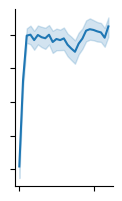

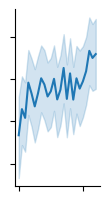

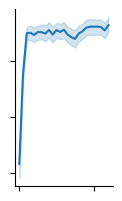

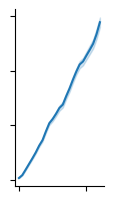

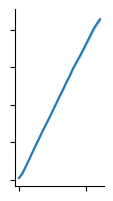

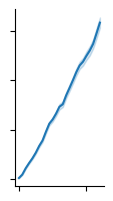

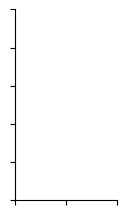

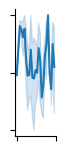

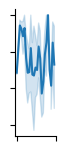

In [122]:
logs = ["video_in_bitrate", "video_out_bitrate", "audio_in_bitrate", "client_video_fps_updated", "audio_out_bitrate", "client_keyframe_encoded_count_updated", "client_keyframe_decoded_count_updated", "client_pli_received_count_updated", "client_fir_received_count_updated", "client_video_resolution_updated"]

for log in logs:
    df_analysis = all_data_df.copy()
    df_analysis = df_analysis.loc[df_analysis["context"] == "track"]
    df_analysis = df_analysis.loc[df_analysis["message"] == log]
    if log == "client_video_resolution_updated":
        df_analysis['width'] = [float(x.split("x")[0]) for x in df_analysis["value"].values]
        df_analysis['height'] = [float(x.split("x")[1]) for x in df_analysis["value"].values]
        df_analysis = df_analysis.groupby(["namespace", "interaction", "user", "sinceCreation_seconds"]).mean(numeric_only=True).reset_index()
        df_analysis = df_analysis.loc[df_analysis["sinceCreation_seconds"] < 250]

        #save weight
        g = sns.relplot(x="sinceCreation_downsampled", y= "width", data=df_analysis, kind="line", aspect=0.7, height=2)
        plt.savefig("plots/" + log + "_width_legend.pdf", bbox_inches='tight')
        g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
        plt.savefig("plots/" + log + "_width.pdf", bbox_inches='tight')
        
        #save height
        g = sns.relplot(x="sinceCreation_downsampled", y= "height", data=df_analysis, kind="line", aspect=0.7, height=2)
        plt.savefig("plots/" + log + "_height_legend.pdf", bbox_inches='tight')
        g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
        plt.savefig("plots/" + log + "_height.pdf", bbox_inches='tight')
    else:    
        df_analysis['value'] = [float(x) for x in df_analysis["value"].values]
        df_analysis = df_analysis.groupby(["namespace", "interaction", "user", "sinceCreation_seconds"]).mean(numeric_only=True).reset_index()
        df_analysis = df_analysis.loc[df_analysis["sinceCreation_seconds"] < 250]
        g = sns.relplot(x="sinceCreation_downsampled", y= "value", data=df_analysis, kind="line", aspect=0.7, height=2.5)
    
    plt.savefig("plots/" + log + "_legend.pdf", bbox_inches='tight')
    g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
    plt.savefig("plots/" + log + ".pdf", bbox_inches='tight')

In [108]:
df_analysis["value"].values[0].split("x")[0]

'600'

In [68]:
all_data_df.columns

Index(['level', 'namespace', 'interaction', 'context', 'time', 'sinceCreation',
       'message', 'user', 'origin', 'payload', 'IP', 'pipeline',
       'audioOptions', 'videoOptions', 'cause', 'current_state', 'offer',
       'source', 'value', 'answer', 'kind', 'ssrc', 'track', 'params', 'mime',
       'count', 'from', 'recording_prefix', 'sinceStart', 'toUser', 'target',
       'stats', 'unit', 'time_seconds', 'error', 'sinceCreation_seconds',
       'sinceCreation_downsampled'],
      dtype='object')

In [70]:
df_analysis = all_data_df.copy()
df_analysis = df_analysis.loc[df_analysis["context"] == "track"]
df_analysis = df_analysis.loc[df_analysis["message"] == "video_in_bitrate"]
df_analysis.columns

Index(['level', 'namespace', 'interaction', 'context', 'time', 'sinceCreation',
       'message', 'user', 'origin', 'payload', 'IP', 'pipeline',
       'audioOptions', 'videoOptions', 'cause', 'current_state', 'offer',
       'source', 'value', 'answer', 'kind', 'ssrc', 'track', 'params', 'mime',
       'count', 'from', 'recording_prefix', 'sinceStart', 'toUser', 'target',
       'stats', 'unit', 'time_seconds', 'error', 'sinceCreation_seconds',
       'sinceCreation_downsampled'],
      dtype='object')

In [72]:
df_analysis["value"]

137       202
141       221
208       171
210       193
257       199
         ... 
10304    1502
10317    1495
10346    1585
10361    1551
10390    1508
Name: value, Length: 36910, dtype: object